In [2]:
import solvers
import torch
import matplotlib.pyplot as plt

In [3]:
H, W = 64, 64
device = "mps"

org = torch.randn((H, W, 6), device=device)
frame = org.clone()

solvers.init_solver(frame)

AttributeError: module 'solvers' has no attribute 'init_solver'

In [ ]:
def add_streamlines(frame, stream_speed, stream_spacing, stream_thickness):

In [ ]:
from multiprocessing import shared_memory
import numpy as np
import threading
import subprocess
import sys
import os
import pygame
import params_window

# CONSTANTS
GRID_RESOLUTION = (1024, 1024)
WINDOW_RES = (768, 768)
FIELDS_BUFFER_NAME = "fields_buffer"
PARAMS_BUFFER_NAME = "params_buffer"
SIM_STEPPER_LOC = "\\scripts\\sim_stepper.py"

# Configuration parameters

SIM_PARAMS = {
    "interaction_strength": 0,
    "interaction_radius": 1,
    "viscosity": 2,
    "diffusion_rate": 3,
    "damping": 4,
    "simulation_speed": 5,
    "solver_iterations": 6,
    "density_scaling": 7,
    "mouse_x": 8,
    "mouse_y": 9,
}

SIM_PARAMS_DEFAULTS = {
    "interaction_strength": 0,
    "interaction_radius": 1,
    "viscosity": 0.1,
    "diffusion_rate": 1,
    "damping": (1 - 1e-2),
    "simulation_speed": 1,
    "solver_iterations": 10,
    "density_scaling": 1,
    "mouse_x": 0,
    "mouse_y": 0,
}

SIM_PARAMS_SIZE = len(SIM_PARAMS) + 1


# METHODS


def destroy_shared_memory(shm):
    shm.close()
    shm.unlink()


def create_shm(BUFFER_NAME, nbytes):
    """
    :param BUFFER_NAME: name of the buffer to locate/store data
    :param nbytes: required size of the buffer to store data
    :return: SharedMemory object
    General method to create shared memory for storing data that can be used by multiple processes.
    """

    print(f"Creating shm with BUFFER_NAME: {BUFFER_NAME} and nbytes {nbytes}")

    try:
        shm = shared_memory.SharedMemory(name=BUFFER_NAME, create=True, size=nbytes)
    except FileExistsError:
        print(f"Shared memory '{BUFFER_NAME}' exists. Cleaning up...")
        shm = shared_memory.SharedMemory(name=BUFFER_NAME)       # Locates existing shared memory by specifying create=False
        destroy_shared_memory(shm)
        print(f"Unlinked existing shared memory. Creating new buffer '{BUFFER_NAME}'")
        shm = shared_memory.SharedMemory(name=BUFFER_NAME, create=True, size=nbytes)

    return shm


def update_simulation_param(param_name, value, shm_params):
    """
    Updates given simulation parameter in shared memory
    """

    param_buffer = np.ndarray((SIM_PARAMS_SIZE,), dtype=np.float32, buffer=shm_params.buf)
    param_buffer[SIM_PARAMS[param_name]] = value


def visualisation_thread():
    """
    Pygame-based visualisation thread to display the shared memory field data
    """
    global shm_params

    shm = shared_memory.SharedMemory(name=FIELDS_BUFFER_NAME)
    buffer = np.ndarray(GRID_RESOLUTION, dtype=np.float32, buffer=shm.buf)
    
    pygame.init()
    screen = pygame.display.set_mode(WINDOW_RES)
    pygame.display.set_caption("Simulation visualisation")

    running = True
    while running:
        # Get keyboard events
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        mouse_X, mouse_Y = pygame.mouse.get_pos()
        update_simulation_param("mouse_x", mouse_X, shm_params)
        update_simulation_param("mouse_y", mouse_Y, shm_params)

        data = buffer.copy()
        surface = pygame.surfarray.make_surface((data * 255).astype(np.uint8))
        screen.blit(pygame.transform.scale(surface, WINDOW_RES), (0, 0))

        pygame.display.flip()

    pygame.quit()
    shm.close()


def launch_sim_stepper():
    """
    Launches the sim_stepper.py script as a separate process
    """

    python_executable = sys.executable
    return subprocess.Popen([python_executable, os.getcwd() + SIM_STEPPER_LOC])


def create_shm_params():
    global shm_params

    try:
        shm_params = shared_memory.SharedMemory(PARAMS_BUFFER_NAME)
    except FileNotFoundError:
        shm_params = create_shm(PARAMS_BUFFER_NAME, SIM_PARAMS_SIZE * 4)

    return shm_params

shm_params = None

if __name__ == "__main__":
    # Creates shared memory and start threads
    
    fields_shm = create_shm(FIELDS_BUFFER_NAME, int(np.prod(GRID_RESOLUTION) * 4))
    
    if not shm_params:
        shm_params = create_shm_params()

    sim_stepper_process = launch_sim_stepper()

    vis_thread = threading.Thread(target=visualisation_thread)
    vis_thread.start()

    # Start tkinter window and handle termination

    try:
        params_window.control_panel()
    except KeyboardInterrupt:
        pass
    finally:
        vis_thread.join()
        sim_stepper_process.terminate()
        destroy_shared_memory(fields_shm)
        destroy_shared_memory(shm_params)
        print("Simulation stopped, subprocess terminated, and shared memory released.")

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV data (adjust the path if needed)
data = np.loadtxt('../logs/log_2025-03-14_09-39-39/data.csv', delimiter=',')



In [7]:
data.shape

(6, 216000)

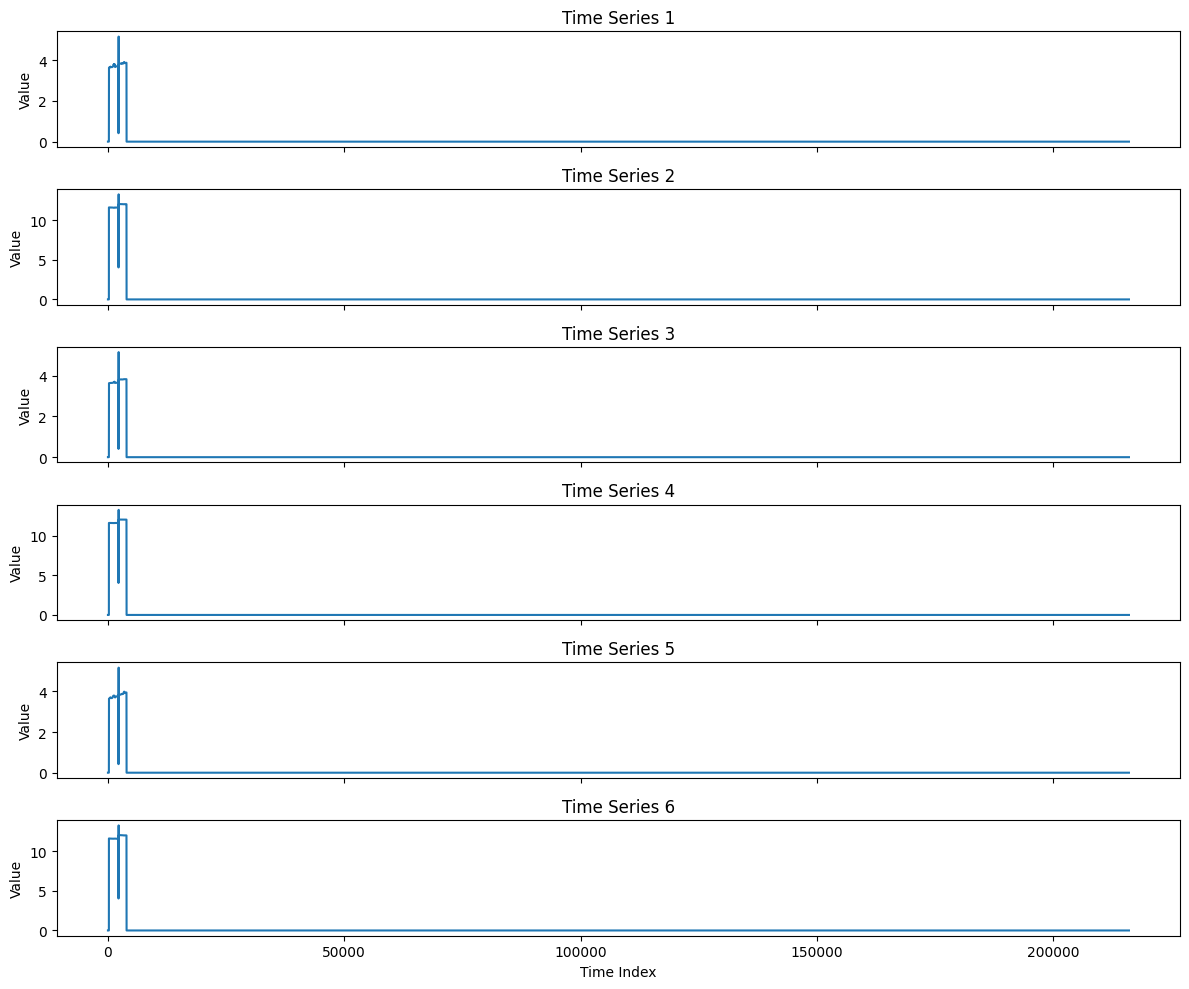

In [8]:
# Create 6 subplots (one for each time series).
fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

# Plot each time series.
for i in range(6):
    axs[i].plot(data[i, :])
    axs[i].set_title(f"Time Series {i+1}")
    axs[i].set_ylabel("Value")

# Set the common x-axis label.
plt.xlabel("Time Index")
plt.tight_layout()
plt.show()